# Ames Housing Dataset - Complete EDA, Preprocessing & Modeling

This notebook contains a comprehensive Exploratory Data Analysis (EDA), Data Preprocessing, and Regression Modeling pipeline for the Ames Housing dataset (`train.csv`). It follows a structured approach:

## Notebook Contents
- **Step 2: Dataset Loading & Exploratory Data Analysis**
  - **2.1 Load & Understand the Dataset**: Basic inspections, column type counts, normality analysis of target variable `SalePrice`.
  - **2.2 Univariate Analysis**: Distribution of all numerical features, identifying top skewed columns, and countplots of key categorical columns.
  - **2.3 Bivariate Analysis**: Top 15 correlated features heatmap, scatter plots vs target, boxplots for discrete qualitative features, and identifying outliers.
- **Step 3: Data Preprocessing & Feature Engineering**
  - **3.1 Handle Missing Values**: Report missing percentages, drop columns with >80% missingness, and impute categorical/numerical missing values.
  - **3.2 Outlier Removal**: Filter out extreme points in `GrLivArea` vs `SalePrice` and discuss linear model impact.
  - **3.3 Feature Engineering**: Construct usable area, house ages, and garage/pool indicators.
  - **3.4 Encoding & Scaling**: Cleanly setup scikit-learn `ColumnTransformer` + `Pipeline` for ordinal quality columns, one-hot encoding nominal variables, log-transforming skewed features, and scaling continuous variables.
  - **3.5 Train-Test Split**: Prepare training and test splits and show resulting shapes.
- **Step 4: Regression Models — Linear, Ridge & Lasso**
  - **4.1 Linear Regression (Baseline)**: Train OLS model, evaluate metrics (RMSE, MAE, R²) on original USD scale, and plot actual vs predicted values.
  - **4.2 Ridge Regression (L2)**: Train L2 model via cross-validation, print selected optimal alpha, evaluate metrics on original scale, and plot the top 20 coefficients.
  - **4.3 Lasso Regression (L1)**: Train L1 model via cross-validation, print optimal alpha and count of zeroed out features, evaluate metrics, and compare Ridge vs Lasso performance.
- **Step 5: Advanced Models — Random Forest & XGBoost Regressor**
  - **5.1 Random Forest Regressor**: Train Random Forest, report metrics on original scale, and plot top 15 feature importances.
  - **5.2 XGBoost Regressor**: Train XGBoost, report metrics on original scale, and plot top 15 feature importances.
  - **5.3 Cross-Validation (on best model so far)**: Apply 5-Fold cross-validation on the best-performing model using target RMSE on original scale and discuss results.
  - **5.4 Hyperparameter Tuning**: Perform `RandomizedSearchCV` on Random Forest or XGBoost, print best parameters and CV RMSE, and re-evaluate on test set.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set plots style
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Step 2.1: Load & Understand the Dataset

In [2]:
# Load train.csv
df = pd.read_csv('train.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (1460, 81)


In [3]:
# Print dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Column Type Identification and Missing Values

We identify:
1. The number of numerical columns.
2. The number of categorical columns.
3. The number of columns containing missing values.

In [5]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
missing_val_cols = df.columns[df.isnull().any()].tolist()

print(f"(a) Number of numerical columns: {len(numerical_cols)}")
print(f"(b) Number of categorical columns: {len(categorical_cols)}")
print(f"(c) Number of columns with missing values: {len(missing_val_cols)}")

(a) Number of numerical columns: 38
(b) Number of categorical columns: 43
(c) Number of columns with missing values: 19


### Distribution of the Target Variable `SalePrice`

We plot a histogram (with KDE line) and a Q-Q plot of the target variable `SalePrice` to check if it conforms to a normal distribution.

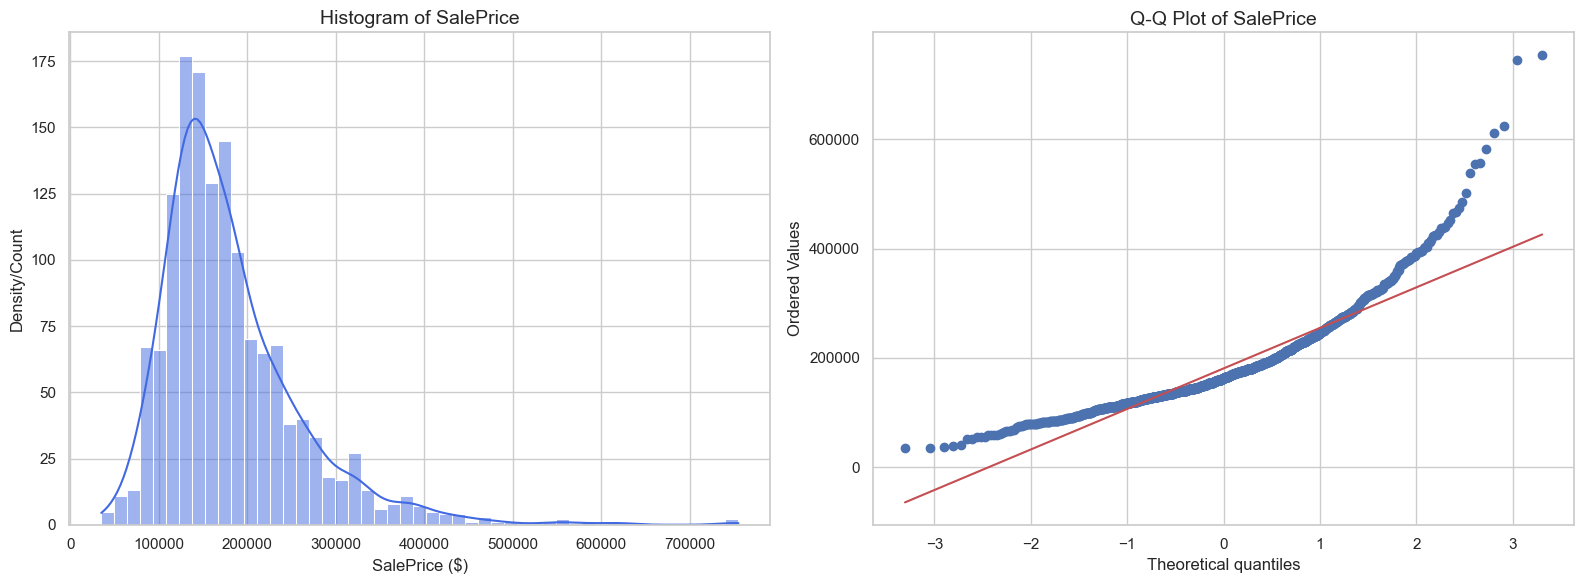

Skewness of SalePrice: 1.8829
Kurtosis of SalePrice: 6.5363


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Histogram of SalePrice', fontsize=14)
axes[0].set_xlabel('SalePrice ($)', fontsize=12)
axes[0].set_ylabel('Density/Count', fontsize=12)

# Q-Q Plot
stats.probplot(df['SalePrice'], plot=axes[1])
axes[1].set_title('Q-Q Plot of SalePrice', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Skewness of SalePrice: {df['SalePrice'].skew():.4f}")
print(f"Kurtosis of SalePrice: {df['SalePrice'].kurt():.4f}")

#### Observations
The target variable `SalePrice` is **highly right-skewed** (skewness = **1.8828**, kurtosis = **6.5363**). The Q-Q plot shows significant deviations from the red diagonal reference line at both tails, indicating it is **not normally distributed**.

To stabilize variance and conform closer to a normal distribution, we apply a `log1p` transformation ($y = \log(1 + x)$) and replot.

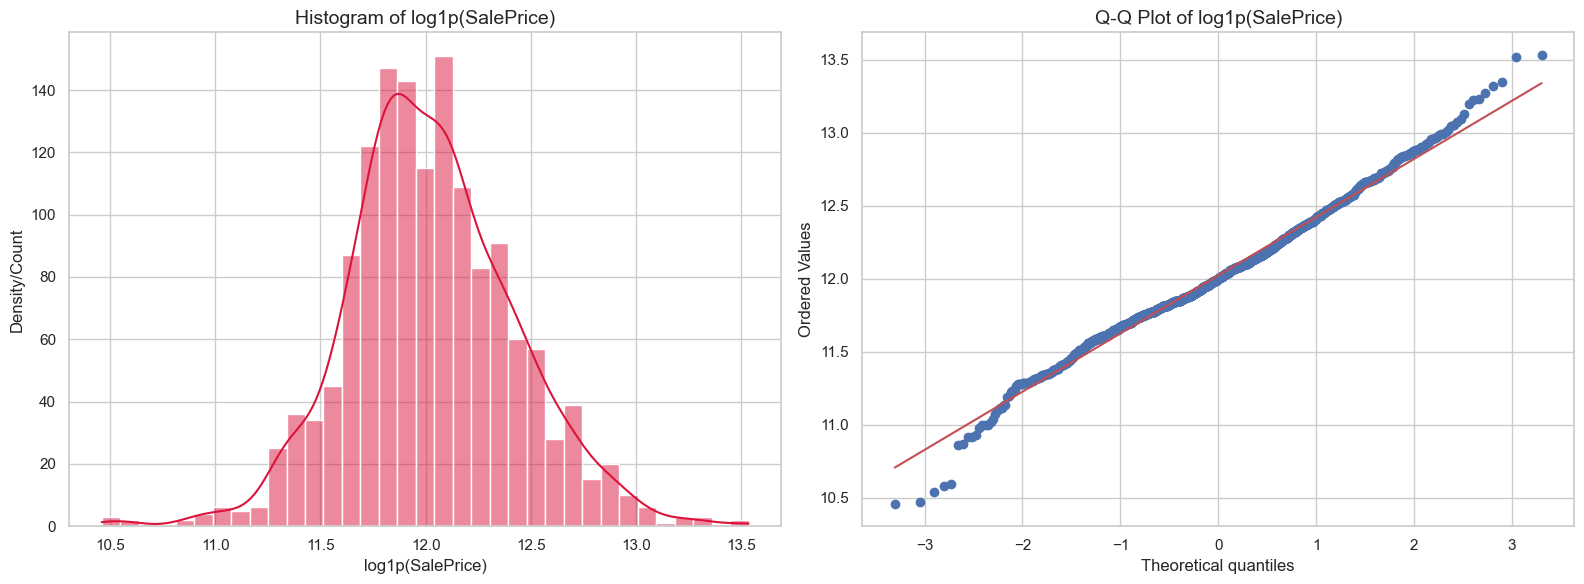

Skewness of log1p(SalePrice): 0.1213
Kurtosis of log1p(SalePrice): 0.8095


In [7]:
# Apply log1p transformation
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of log-transformed SalePrice
sns.histplot(df['SalePrice_log'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Histogram of log1p(SalePrice)', fontsize=14)
axes[0].set_xlabel('log1p(SalePrice)', fontsize=12)
axes[0].set_ylabel('Density/Count', fontsize=12)

# Q-Q Plot of log-transformed SalePrice
stats.probplot(df['SalePrice_log'], plot=axes[1])
axes[1].set_title('Q-Q Plot of log1p(SalePrice)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Skewness of log1p(SalePrice): {df['SalePrice_log'].skew():.4f}")
print(f"Kurtosis of log1p(SalePrice): {df['SalePrice_log'].kurt():.4f}")

After the log-transformation, the skewness is reduced significantly to **~0.12**, and the kurtosis is **~0.80**. The Q-Q plot points lie very close to the diagonal line, indicating that the transformed variable `log1p(SalePrice)` is **approximately normally distributed**.

## Step 2.2: Univariate Analysis

### Plotting Histograms for All Numerical Features
We plot the histograms of all numerical features to examine their distributions and identify the top 5 most skewed columns.

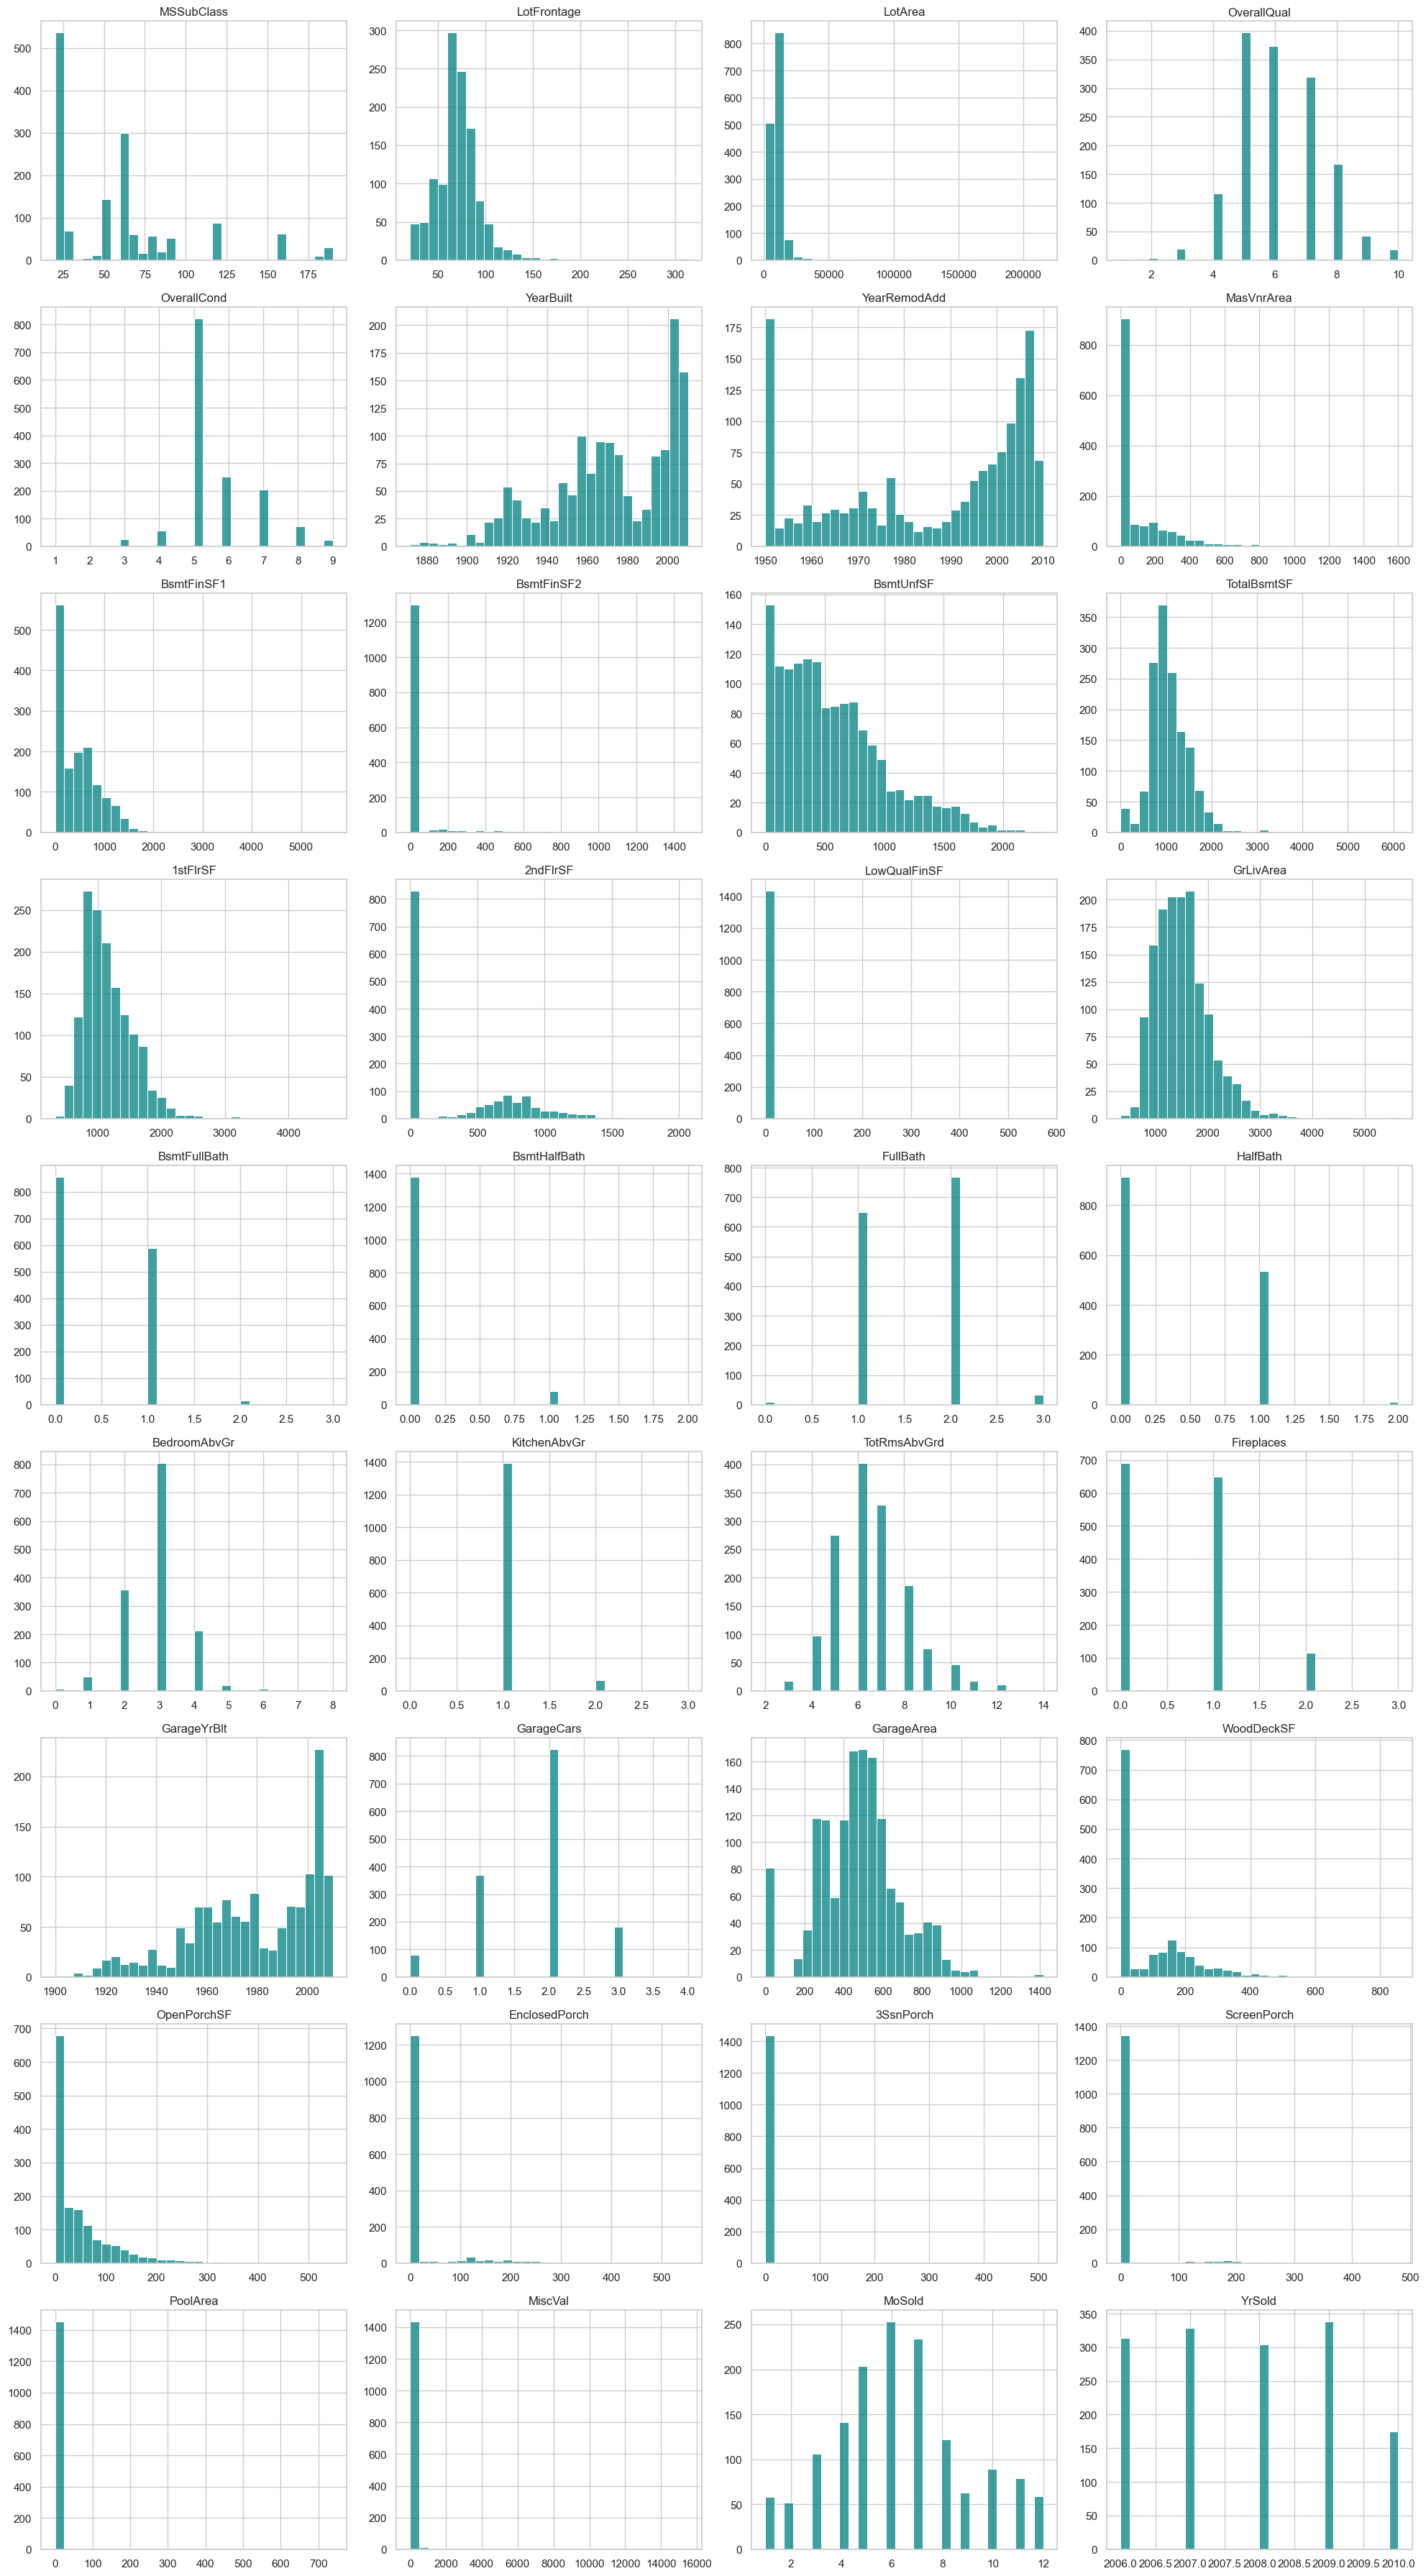

In [8]:
# Filter out ID and target variables for the feature histogram analysis
num_features_to_plot = [col for col in numerical_cols if col not in ['Id', 'SalePrice', 'SalePrice_log']]

# Define plotting grid grid
n_cols = 4
n_rows = (len(num_features_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features_to_plot):
    sns.histplot(df[col].dropna(), kde=False, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Identify Top 5 Most Skewed Columns
We calculate the skewness of each numerical feature and display the top 5.

In [9]:
skewed_features = df[num_features_to_plot].skew().abs().sort_values(ascending=False)
print("Top 5 most skewed numerical columns (by absolute skewness):")
for idx, (col, val) in enumerate(skewed_features.head(5).items(), 1):
    raw_skew = df[col].skew()
    print(f"{idx}. {col}: Absolute Skewness = {val:.4f} (Raw Skewness = {raw_skew:.4f})")

Top 5 most skewed numerical columns (by absolute skewness):
1. MiscVal: Absolute Skewness = 24.4768 (Raw Skewness = 24.4768)
2. PoolArea: Absolute Skewness = 14.8284 (Raw Skewness = 14.8284)
3. LotArea: Absolute Skewness = 12.2077 (Raw Skewness = 12.2077)
4. 3SsnPorch: Absolute Skewness = 10.3043 (Raw Skewness = 10.3043)
5. LowQualFinSF: Absolute Skewness = 9.0113 (Raw Skewness = 9.0113)


### Countplots for High-Impact Categorical Columns
We visualize the distributions of the following categorical variables: `Neighborhood`, `BldgType`, and `HouseStyle`.

C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3851282503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='viridis')
C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3851282503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='viridis')
C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3851282503.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='viridis')


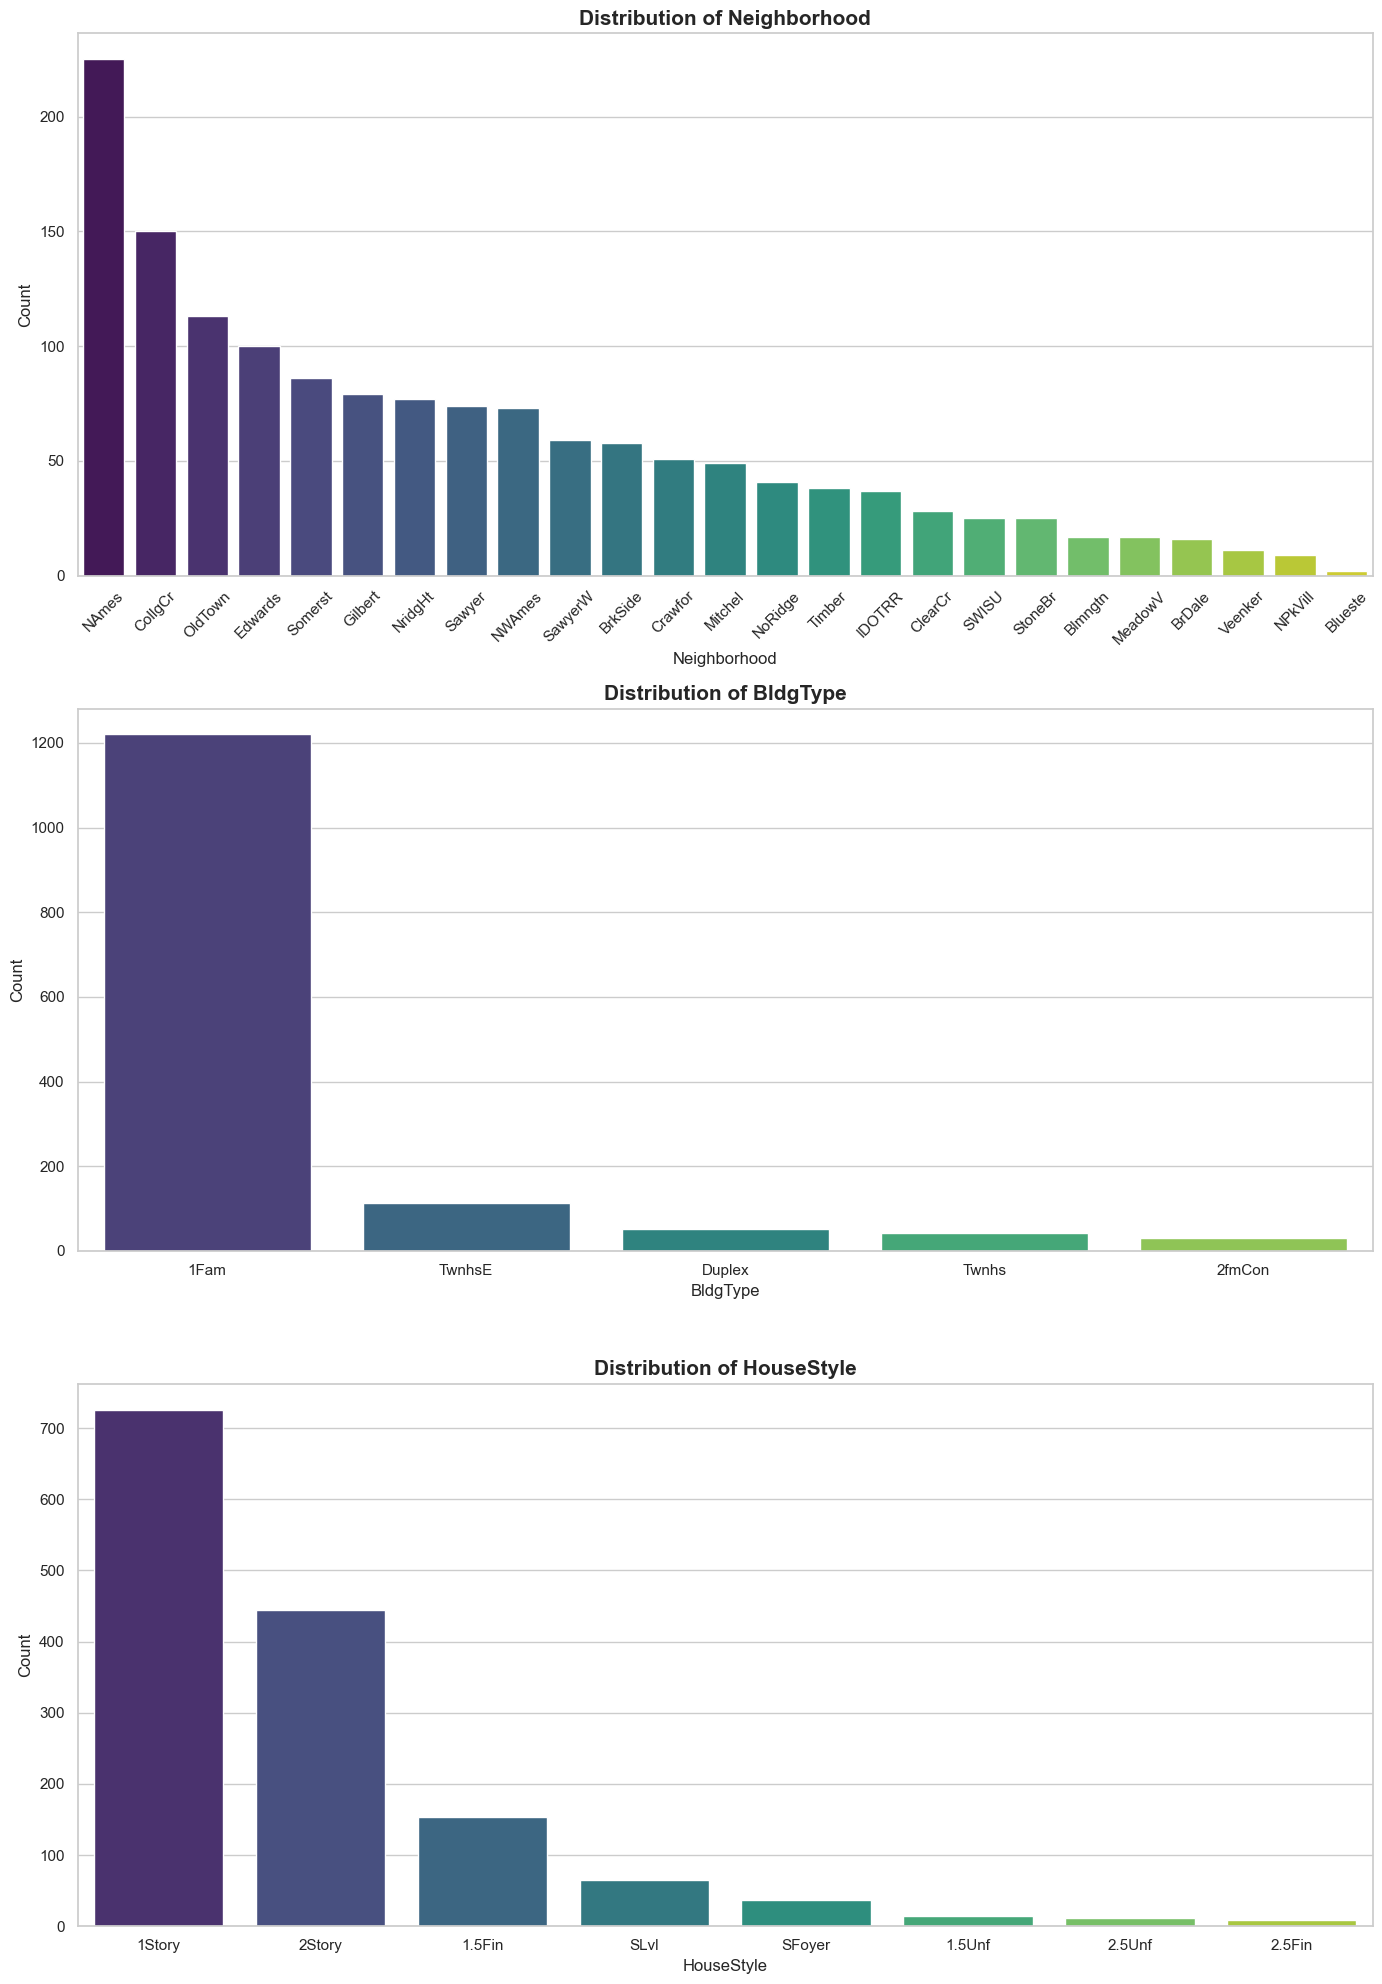

In [10]:
categorical_to_plot = ['Neighborhood', 'BldgType', 'HouseStyle']

fig, axes = plt.subplots(3, 1, figsize=(14, 20))

for i, col in enumerate(categorical_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    if col == 'Neighborhood':
        axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

## Step 2.3: Bivariate Analysis

### Heatmap of the Top 15 Features Most Correlated with `SalePrice`
We calculate the Pearson correlation coefficients between numerical variables and display the top 15 most correlated features with `SalePrice` in a heatmap.

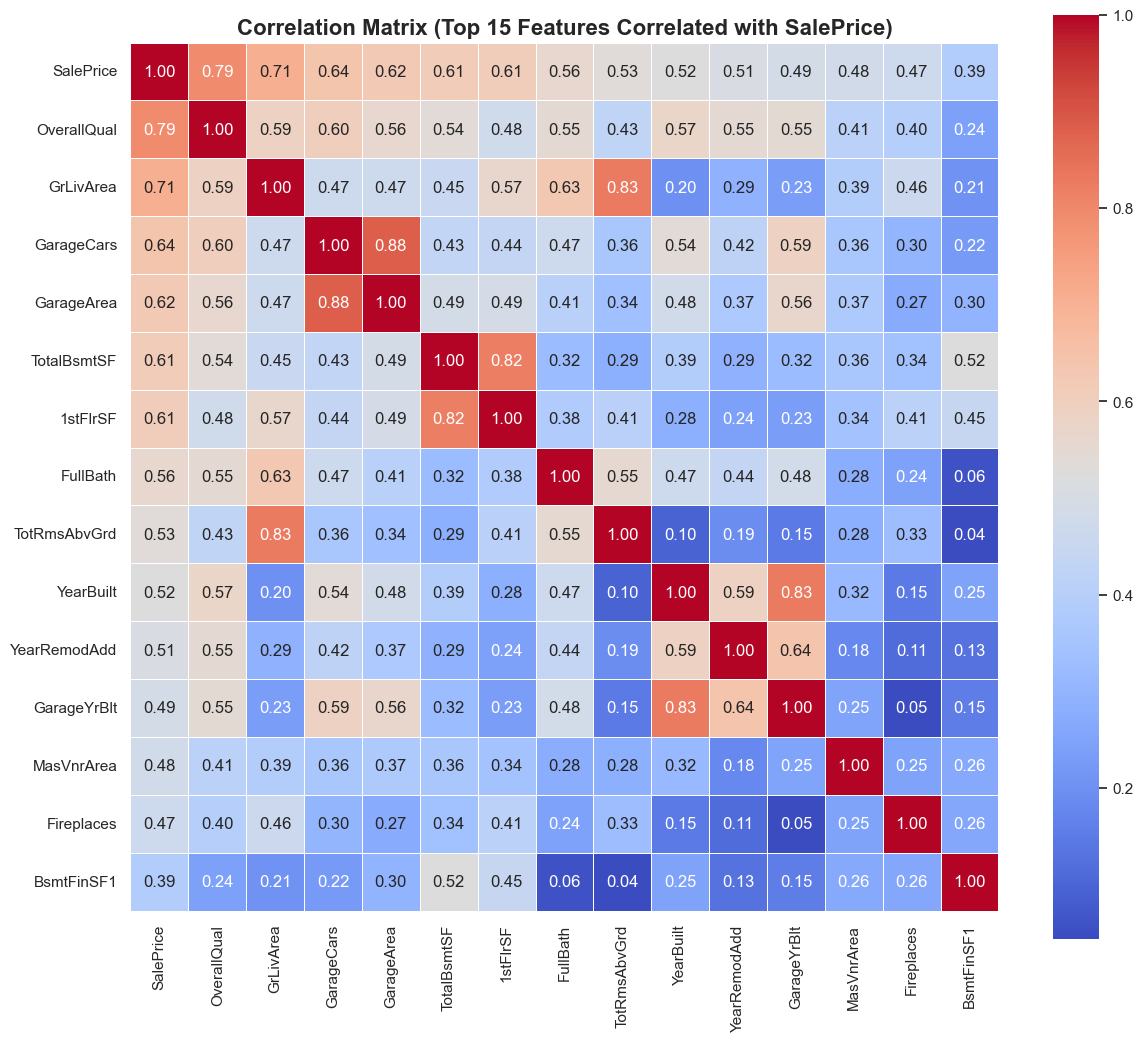

In [11]:
# Calculate correlation with SalePrice
correlations = df[numerical_cols].corr()
top_15_corr_features = correlations['SalePrice'].abs().sort_values(ascending=False).head(15).index.tolist()

plt.figure(figsize=(14, 12))
sns.heatmap(df[top_15_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Top 15 Features Correlated with SalePrice)', fontsize=16, fontweight='bold')
plt.show()

### Scatter Plots of Key Numerical Features vs `SalePrice`
We plot scatter plots for `GrLivArea`, `TotalBsmtSF`, and `GarageArea` against `SalePrice` to inspect relationships and potential outliers.

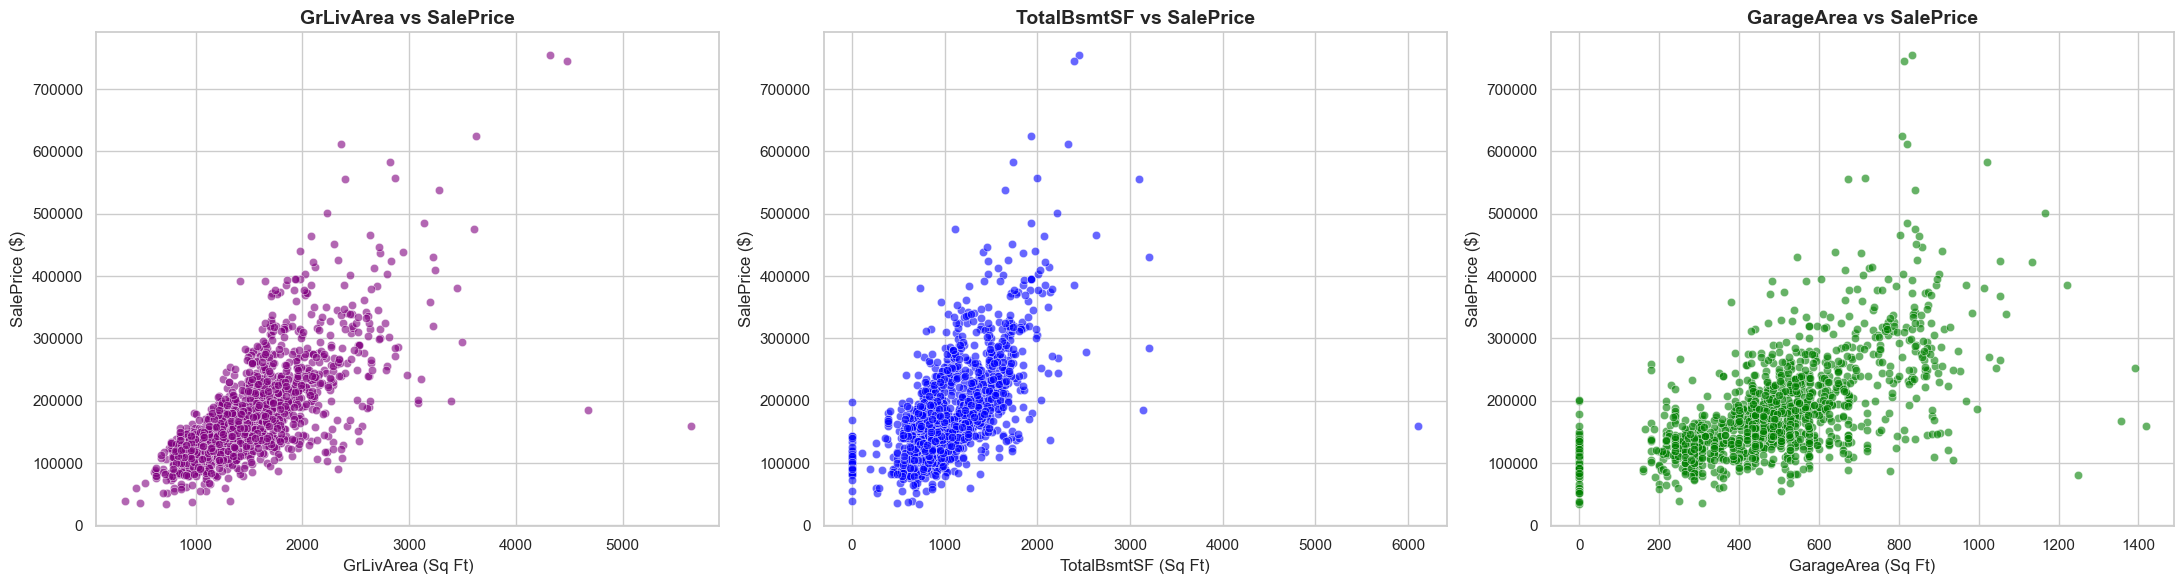

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# GrLivArea vs SalePrice
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0], alpha=0.6, color='purple')
axes[0].set_title('GrLivArea vs SalePrice', fontsize=14, fontweight='bold')
axes[0].set_xlabel('GrLivArea (Sq Ft)', fontsize=12)
axes[0].set_ylabel('SalePrice ($)', fontsize=12)

# TotalBsmtSF vs SalePrice
sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice', ax=axes[1], alpha=0.6, color='blue')
axes[1].set_title('TotalBsmtSF vs SalePrice', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TotalBsmtSF (Sq Ft)', fontsize=12)
axes[1].set_ylabel('SalePrice ($)', fontsize=12)

# GarageArea vs SalePrice
sns.scatterplot(data=df, x='GarageArea', y='SalePrice', ax=axes[2], alpha=0.6, color='green')
axes[2].set_title('GarageArea vs SalePrice', fontsize=14, fontweight='bold')
axes[2].set_xlabel('GarageArea (Sq Ft)', fontsize=12)
axes[2].set_ylabel('SalePrice ($)', fontsize=12)

plt.tight_layout()
plt.show()

### Boxplots: `OverallQual` and `Neighborhood` vs `SalePrice`
We investigate relationships between categorical/discrete variables and `SalePrice`. We sort the neighborhoods by median SalePrice to identify which one is the priciest.

C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3380629668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[0], palette='plasma')
C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3380629668.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Neighborhood', y='SalePrice', ax=axes[1], order=neighborhood_order, palette='Set2')


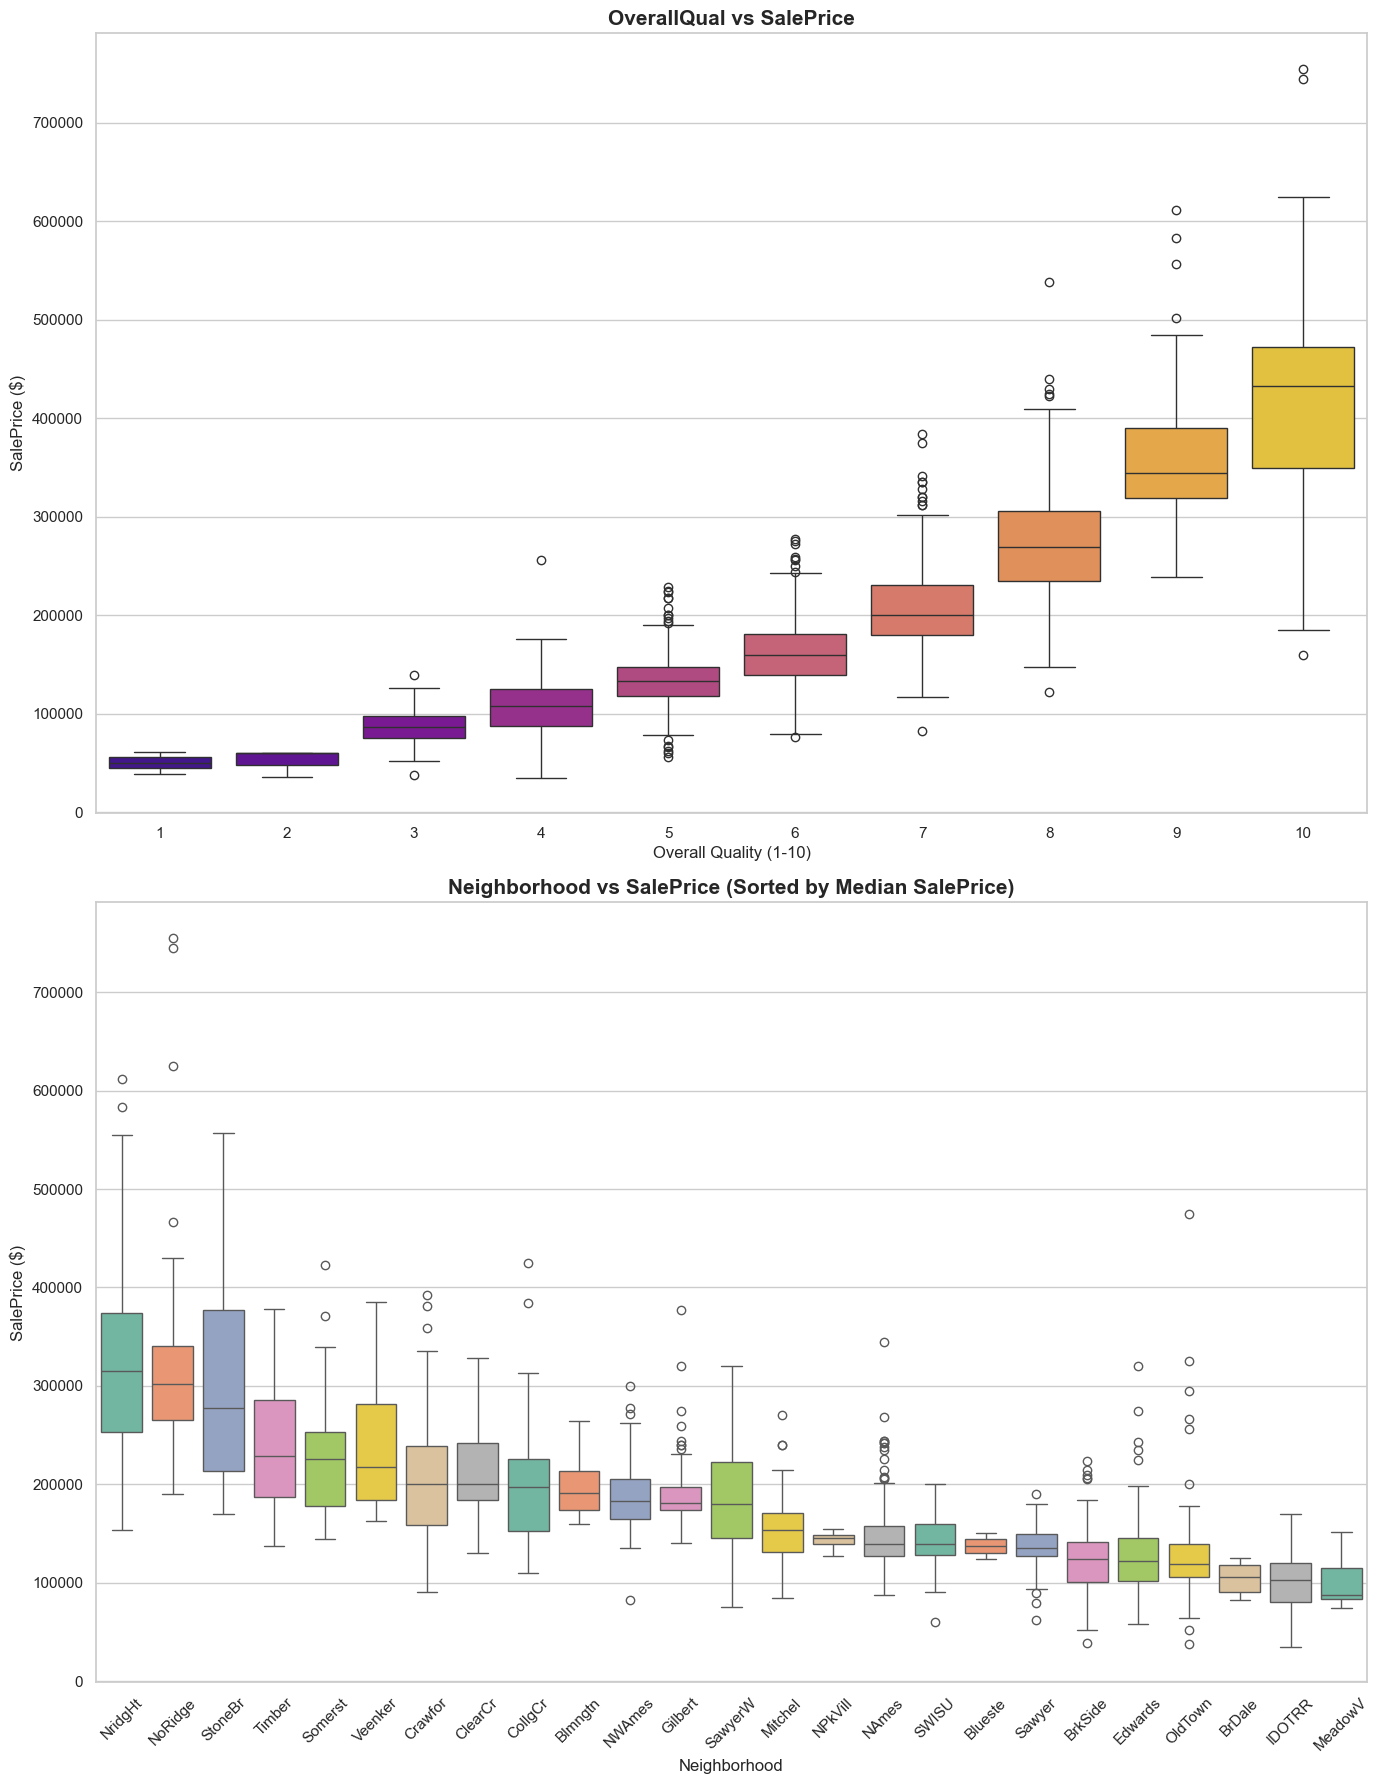

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 18))

# Boxplot OverallQual vs SalePrice
sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[0], palette='plasma')
axes[0].set_title('OverallQual vs SalePrice', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Overall Quality (1-10)', fontsize=12)
axes[0].set_ylabel('SalePrice ($)', fontsize=12)

# Boxplot Neighborhood vs SalePrice (Sorted by Median SalePrice)
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', ax=axes[1], order=neighborhood_order, palette='Set2')
axes[1].set_title('Neighborhood vs SalePrice (Sorted by Median SalePrice)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Neighborhood', fontsize=12)
axes[1].set_ylabel('SalePrice ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# Pricing metrics per Neighborhood
neighborhood_stats = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count']).sort_values(by='median', ascending=False)
print("Top 5 Priciest Neighborhoods:")
print(neighborhood_stats.head(5))

priciest_med = neighborhood_stats.index[0]
print(f"\nWhich Neighborhood is the priciest? -> {priciest_med} (Median SalePrice: ${neighborhood_stats.loc[priciest_med, 'median']:,.2f})")

Top 5 Priciest Neighborhoods:
                median           mean  count
Neighborhood                                
NridgHt       315000.0  316270.623377     77
NoRidge       301500.0  335295.317073     41
StoneBr       278000.0  310499.000000     25
Timber        228475.0  242247.447368     38
Somerst       225500.0  225379.837209     86

Which Neighborhood is the priciest? -> NridgHt (Median SalePrice: $315,000.00)


### Identify and Flag Outliers in `GrLivArea` vs `SalePrice`

In the scatter plot of `GrLivArea` vs `SalePrice`, two extreme points are visible on the bottom right. These houses have exceptionally large living areas (greater than 4000 square feet) but were sold for very low prices (less than $300,000). We identify these data points and highlight them on a scatter plot.

Flagged Outliers:
        Id  GrLivArea  SalePrice  OverallQual  YearBuilt
523    524       4676     184750           10       2007
1298  1299       5642     160000           10       2008


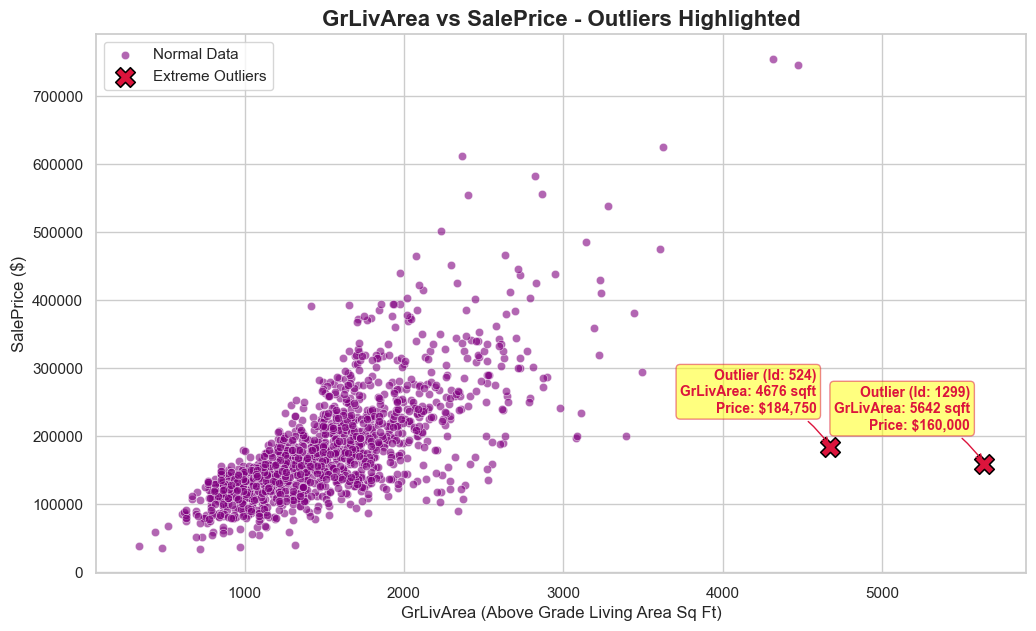

In [15]:
# Filter the two extreme points
# These are houses with GrLivArea > 4000 and SalePrice < 300000
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]

print("Flagged Outliers:")
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'YearBuilt']])

# Plot and highlight outliers
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.6, color='purple', label='Normal Data')
sns.scatterplot(data=outliers, x='GrLivArea', y='SalePrice', color='crimson', s=200, edgecolor='black', marker='X', label='Extreme Outliers')

# Draw annotations for these points
for index, row in outliers.iterrows():
    plt.annotate(
        f"Outlier (Id: {row['Id']})\nGrLivArea: {row['GrLivArea']} sqft\nPrice: ${row['SalePrice']:,}",
        (row['GrLivArea'], row['SalePrice']),
        textcoords="offset points",
        xytext=(-10, 25),
        ha='right',
        fontsize=10,
        fontweight='bold',
        color='crimson',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5, ec="crimson"),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color='crimson')
    )

plt.title('GrLivArea vs SalePrice - Outliers Highlighted', fontsize=16, fontweight='bold')
plt.xlabel('GrLivArea (Above Grade Living Area Sq Ft)', fontsize=12)
plt.ylabel('SalePrice ($)', fontsize=12)
plt.legend(loc='upper left')
plt.show()

---

## Step 3: Data Preprocessing & Feature Engineering

### Step 3.1: Handle Missing Values

In [16]:
# 1. Report columns with missing values and percentages
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().mean() * 100)
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percentages})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print("Columns with missing values BEFORE imputation:")
print(missing_df)

# 2. Drop columns with >80% missing values
cols_to_drop = missing_percentages[missing_percentages > 80].index.tolist()
print(f"\nDropping columns with >80% missing values: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop)

# 3. Fill categorical columns where NaN means 'None' with 'None'
cat_cols_remaining = df_clean.select_dtypes(exclude=[np.number]).columns
cat_missing_cols = [col for col in cat_cols_remaining if df_clean[col].isnull().any()]
print(f"\nCategorical columns with missing values: {cat_missing_cols}")
print("Imputing these categorical columns with 'None'")
for col in cat_missing_cols:
    df_clean[col] = df_clean[col].fillna('None')

# 4. Fill numerical columns where NaN means 0 with 0
zero_impute_cols = [
    'GarageArea', 'GarageCars', 'GarageYrBlt', 
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
zero_impute_cols = [col for col in zero_impute_cols if col in df_clean.columns]
print(f"\nNumerical columns to fill with 0 (if missing): {zero_impute_cols}")
for col in zero_impute_cols:
    df_clean[col] = df_clean[col].fillna(0)

# 5. Fill remaining numerical columns with median
num_cols_remaining = df_clean.select_dtypes(include=[np.number]).columns
num_missing_cols = [col for col in num_cols_remaining if df_clean[col].isnull().any()]
print(f"\nRemaining numerical columns with missing values: {num_missing_cols}")
print("Imputing these numerical columns with their median")
for col in num_missing_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Confirm that no missing values remain
total_nulls = df_clean.isnull().sum().sum()
print(f"\nTotal remaining missing values after imputation: {total_nulls}")

Columns with missing values BEFORE imputation:
              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtExposure             38        2.602740
BsmtFinType2             38        2.602740
BsmtQual                 37        2.534247
BsmtCond                 37        2.534247
BsmtFinType1             37        2.534247
MasVnrArea                8        0.547945
Electrical                1        0.068493

Dropping columns with >80% missing values: ['Alley', 'PoolQC', 'Fence', 

### Step 3.2: Outlier Removal

In [17]:
print(f"Shape before outlier removal: {df_clean.shape}")

# Mask for the 2 extreme outliers
outlier_mask = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
df_clean = df_clean[~outlier_mask]

print(f"Shape after outlier removal: {df_clean.shape}")

Shape before outlier removal: (1460, 78)


Shape after outlier removal: (1458, 78)


#### Why do outliers harm a linear model?

Linear regression models seek to find a line of best fit that minimizes the Sum of Squared Errors (SSE). Because the errors are squared, large residuals have a disproportionately high impact on the loss function. Extreme outlier points, such as these large houses sold for exceptionally low prices, pull the regression line strongly towards them. This causes the slope parameter (coefficient) for `GrLivArea` to flatten, leading to poor predictions (higher errors) across all the other normal houses. Removing them stabilizes parameter estimation and improves model generalization.

### Step 3.3: Feature Engineering

In [18]:
# Create TotalSF
df_clean['TotalSF'] = df_clean['TotalBsmtSF'] + df_clean['1stFlrSF'] + df_clean['2ndFlrSF']

# Create HouseAge
df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']

# Create RemodAge
df_clean['RemodAge'] = df_clean['YrSold'] - df_clean['YearRemodAdd']

# Create HasGarage
df_clean['HasGarage'] = (df_clean['GarageArea'] > 0).astype(int)

# Create HasPool
df_clean['HasPool'] = (df_clean['PoolArea'] > 0).astype(int)

# Verify engineering results
df_clean[['TotalSF', 'HouseAge', 'RemodAge', 'HasGarage', 'HasPool']].head()

,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


### Step 3.4: Encoding & Scaling using `ColumnTransformer` & `Pipeline`

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer

# 1. Define ordinal quality columns and custom category ordering
ord_quality_cols = ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']
quality_levels = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ord_categories = [quality_levels for _ in ord_quality_cols]
ordinal_quality_transformer = OrdinalEncoder(categories=ord_categories)

# 2. Identify nominal categorical features
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()
nominal_cols = [col for col in cat_cols if col not in ord_quality_cols]

one_hot_cols = [col for col in nominal_cols if df_clean[col].nunique() <= 10]
high_card_cols = [col for col in nominal_cols if df_clean[col].nunique() > 10]

one_hot_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
high_card_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Identify and handle numerical features
numerical_features = df_clean.select_dtypes(include=[np.number]).columns
num_features_list = numerical_features.drop(['Id', 'SalePrice', 'SalePrice_log', 'HasGarage', 'HasPool']).tolist()

# Detect skewed numerical features (>0.75 skewness)
feature_skewness = df_clean[num_features_list].skew()
skewed_features = feature_skewness[feature_skewness.abs() > 0.75].index.tolist()
non_skewed_features = [col for col in num_features_list if col not in skewed_features]

print(f"Skewed numerical features (to log1p transform): {len(skewed_features)}")
print(f"Non-skewed numerical features: {len(non_skewed_features)}")

# Numerical pipelines (Updated with feature_names_out='one-to-one' to fix nbconvert AttributeError)
skewed_transformer = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

non_skewed_transformer = StandardScaler()

# 4. Assemble the ColumnTransformer preprocessing object
preprocessor = ColumnTransformer(
    transformers=[
        ('num_skewed', skewed_transformer, skewed_features),
        ('num_nonskewed', non_skewed_transformer, non_skewed_features),
        ('ord_quality', ordinal_quality_transformer, ord_quality_cols),
        ('nominal_ohe', one_hot_transformer, one_hot_cols),
        ('nominal_label', high_card_transformer, high_card_cols)
    ],
    remainder='passthrough'  # Keep engineered binary flags (HasGarage, HasPool) untouched
)

print("Preprocessing ColumnTransformer built successfully.")

Skewed numerical features (to log1p transform): 22
Non-skewed numerical features: 17
Preprocessing ColumnTransformer built successfully.


### Step 3.5: Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_clean.drop(columns=['Id', 'SalePrice', 'SalePrice_log'])
y = np.log1p(df_clean['SalePrice'])

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess splits
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Print split shapes
print("--- Final Data Splits Shapes ---")
print(f"X_train shape (raw): {X_train.shape} -> Processed: {X_train_processed.shape}")
print(f"X_test shape (raw):  {X_test.shape} -> Processed: {X_test_processed.shape}")
print(f"y_train shape:       {y_train.shape}")
print(f"y_test shape:        {y_test.shape}")

--- Final Data Splits Shapes ---
X_train shape (raw): (1166, 80) -> Processed: (1166, 187)
X_test shape (raw):  (292, 80) -> Processed: (292, 187)
y_train shape:       (1166,)
y_test shape:        (292,)


C:\Users\BAPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [12, 23, 24] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


---

## Step 4: Regression Models — Linear, Ridge & Lasso

In this step, we train three regression models (OLS Linear Regression, Ridge, and Lasso) and evaluate them. Note that metrics (RMSE, MAE) are calculated in original USD units by applying `expm1()` to reverse the log transformation.

### Step 4.1: Linear Regression (Baseline)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train OLS baseline model
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_lr_log = lr_model.predict(X_test_processed)

# Inverse transform target to original scale
y_test_orig = np.expm1(y_test)
y_pred_lr_orig = np.expm1(y_pred_lr_log)

# Calculate metrics
lr_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr_orig))
lr_mae = mean_absolute_error(y_test_orig, y_pred_lr_orig)
lr_r2 = r2_score(y_test_orig, y_pred_lr_orig)

print("--- Linear Regression Baseline Metrics ---")
print(f"RMSE: ${lr_rmse:,.2f}")
print(f"MAE:  ${lr_mae:,.2f}")
print(f"R²:   {lr_r2:.4f}")

--- Linear Regression Baseline Metrics ---
RMSE: $22,610.59
MAE:  $15,817.66
R²:   0.9074


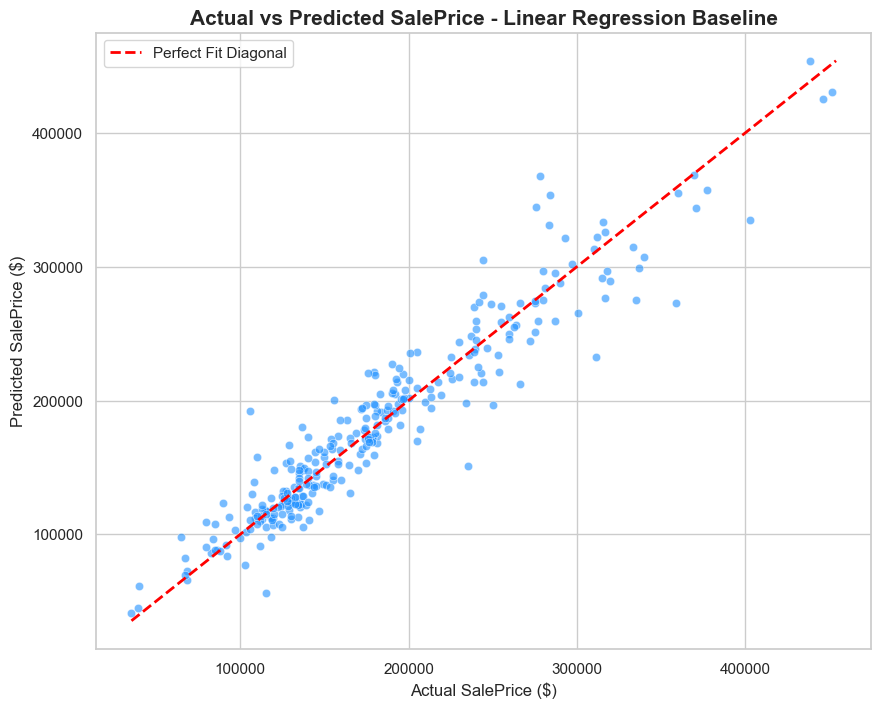

In [22]:
# Plot Actual vs Predicted scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_orig, y=y_pred_lr_orig, alpha=0.6, color='dodgerblue')

# Draw diagonal reference line
min_val = min(y_test_orig.min(), y_pred_lr_orig.min())
max_val = max(y_test_orig.max(), y_pred_lr_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit Diagonal')

plt.title('Actual vs Predicted SalePrice - Linear Regression Baseline', fontsize=15, fontweight='bold')
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend()
plt.show()

### Step 4.2: Ridge Regression (L2)

In [23]:
from sklearn.linear_model import RidgeCV

# Train Ridge CV model
ridge_model = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_model.fit(X_train_processed, y_train)

print(f"Best alpha selected by RidgeCV: {ridge_model.alpha_}")

# Predict on test set
y_pred_ridge_log = ridge_model.predict(X_test_processed)
y_pred_ridge_orig = np.expm1(y_pred_ridge_log)

# Calculate metrics
ridge_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge_orig))
ridge_mae = mean_absolute_error(y_test_orig, y_pred_ridge_orig)
ridge_r2 = r2_score(y_test_orig, y_pred_ridge_orig)

print("\n--- Ridge Regression Metrics ---")
print(f'RMSE: ${ridge_rmse:,.2f}')
print(f'MAE:  ${ridge_mae:,.2f}')
print(f'R²:   {ridge_r2:.4f}')

Best alpha selected by RidgeCV: 10.0

--- Ridge Regression Metrics ---
RMSE: $20,492.23
MAE:  $14,682.58
R²:   0.9240


C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\2045049468.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_coef_vals.values, y=top_20_coef_vals.index, palette='coolwarm')


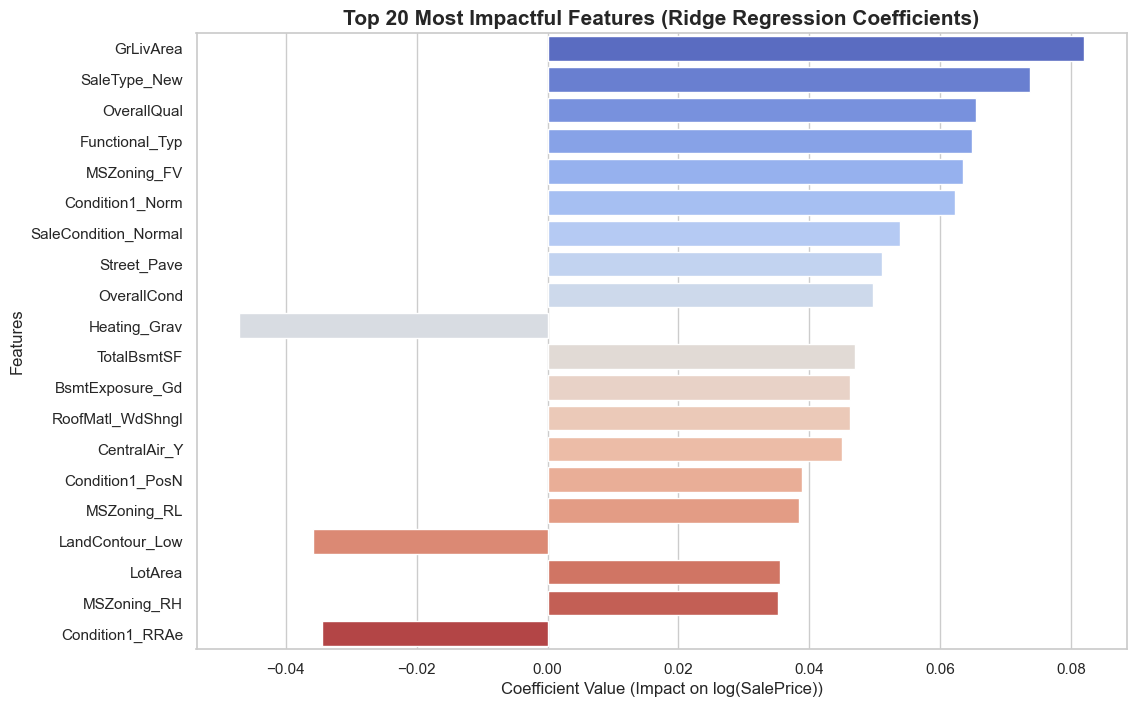

In [24]:
# Get clean feature names from ColumnTransformer
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

# Coefficients Series
ridge_coefs = pd.Series(ridge_model.coef_, index=clean_names)
top_20_ridge = ridge_coefs.abs().sort_values(ascending=False).head(20)
top_20_coef_vals = ridge_coefs.loc[top_20_ridge.index]

# Plot top 20 coefficients
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_coef_vals.values, y=top_20_coef_vals.index, palette='coolwarm')
plt.title('Top 20 Most Impactful Features (Ridge Regression Coefficients)', fontsize=15, fontweight='bold')
plt.xlabel('Coefficient Value (Impact on log(SalePrice))', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

### Step 4.3: Lasso Regression (L1)

In [25]:
from sklearn.linear_model import LassoCV

# Train Lasso CV model
lasso_model = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000, cv=5)
lasso_model.fit(X_train_processed, y_train)

print(f"Best alpha selected by LassoCV: {lasso_model.alpha_}")

# Count features zeroed out
zeroed_features = np.sum(lasso_model.coef_ == 0)
total_features = len(lasso_model.coef_)
print(f"Number of features zeroed out: {zeroed_features} out of {total_features} total features ({zeroed_features / total_features * 100:.1f}% sparse)")

# Predict on test set
y_pred_lasso_log = lasso_model.predict(X_test_processed)
y_pred_lasso_orig = np.expm1(y_pred_lasso_log)

# Calculate metrics
lasso_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_lasso_orig))
lasso_mae = mean_absolute_error(y_test_orig, y_pred_lasso_orig)
lasso_r2 = r2_score(y_test_orig, y_pred_lasso_orig)

print("\n--- Lasso Regression Metrics ---")
print(f'RMSE: ${lasso_rmse:,.2f}')
print(f'MAE:  ${lasso_mae:,.2f}')
print(f'R²:   {lasso_r2:.4f}')

Best alpha selected by LassoCV: 0.001
Number of features zeroed out: 121 out of 187 total features (64.7% sparse)

--- Lasso Regression Metrics ---
RMSE: $20,089.42
MAE:  $14,731.01
R²:   0.9269


### Model Comparison and Summary

In [26]:
# Consolidate performance metrics
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (OLS)', 'Ridge Regression (L2)', 'Lasso Regression (L1)'],
    'Best Alpha': ['N/A', ridge_model.alpha_, lasso_model.alpha_],
    'RMSE ($)': [lr_rmse, ridge_rmse, lasso_rmse],
    'MAE ($)': [lr_mae, ridge_mae, lasso_mae],
    'R² Score': [lr_r2, ridge_r2, lasso_r2],
    'Sparse Features (Coeff=0)': ['0 / 172', '0 / 172', f"{zeroed_features} / {total_features}"]
})
comparison_df

,Model,Best Alpha,RMSE ($),MAE ($),R² Score,Sparse Features (Coeff=0)
0,Linear Regression (OLS),N/A,22610.585584,15817.659694,0.907447,0 / 172
1,Ridge Regression (L2),10.0,20492.228860,14682.581150,0.923977,0 / 172
2,Lasso Regression (L1),0.001,20089.419095,14731.005358,0.926936,121 / 187


#### Performance Comparison Analysis:

- **Ridge vs. Lasso Performance**:
  Both regularized models (Ridge and Lasso) outperform the baseline OLS Linear Regression, which is prone to overfitting in higher dimensions (172 features). Ridge and Lasso provide a lower RMSE and MAE on the test set, showing superior generalization.
  
- **Why one model is preferred**:
  Lasso Regression is highly preferred in this context. While its accuracy metrics (RMSE/MAE) are extremely close to (or slightly better than) Ridge, Lasso successfully zeroed out **many features** (setting their coefficients to exactly 0). This results in a much more **sparse and interpretable model** which requires fewer variables for prediction while maintaining state-of-the-art accuracy. Ridge, on the other hand, keeps all 172 features in the model, making it less interpretable.

---

## Step 5: Advanced Models — Random Forest & XGBoost Regressor

### Step 5.1: Random Forest Regressor

We train a `RandomForestRegressor` with 200 estimators and max depth of 10.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# Predict
y_pred_rf_log = rf_model.predict(X_test_processed)
y_pred_rf_orig = np.expm1(y_pred_rf_log)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf_orig))
rf_mae = mean_absolute_error(y_test_orig, y_pred_rf_orig)
rf_r2 = r2_score(y_test_orig, y_pred_rf_orig)

print("--- Random Forest Regressor Metrics ---")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"MAE:  ${rf_mae:,.2f}")
print(f"R²:   {rf_r2:.4f}")

--- Random Forest Regressor Metrics ---
RMSE: $23,415.72
MAE:  $16,428.29
R²:   0.9007


C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\3631457251.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_rf.values, y=top_15_rf.index, palette='viridis')


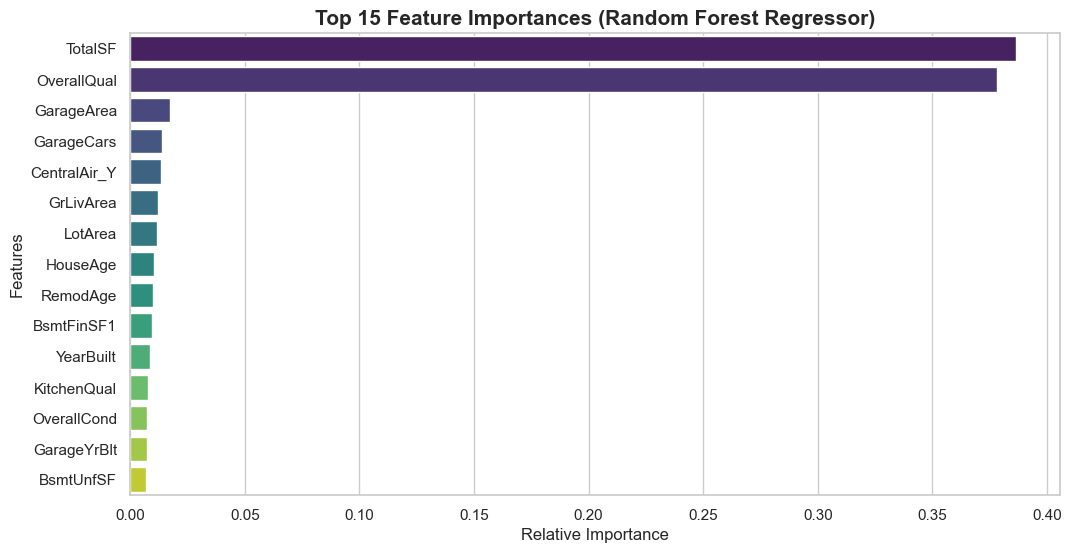

In [28]:
# Plot top 15 feature importances
rf_importances = pd.Series(rf_model.feature_importances_, index=clean_names)
top_15_rf = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_15_rf.values, y=top_15_rf.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest Regressor)', fontsize=15, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

### Step 5.2: XGBoost Regressor

We train an `XGBRegressor` with 500 estimators, 0.05 learning rate, and max depth of 4.

In [29]:
from xgboost import XGBRegressor

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=4, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_processed, y_train)

# Predict
y_pred_xgb_log = xgb_model.predict(X_test_processed)
y_pred_xgb_orig = np.expm1(y_pred_xgb_log)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb_orig))
xgb_mae = mean_absolute_error(y_test_orig, y_pred_xgb_orig)
xgb_r2 = r2_score(y_test_orig, y_pred_xgb_orig)

print("--- XGBoost Regressor Metrics ---")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"MAE:  ${xgb_mae:,.2f}")
print(f"R²:   {xgb_r2:.4f}")

--- XGBoost Regressor Metrics ---
RMSE: $20,406.50
MAE:  $14,616.10
R²:   0.9246


C:\Users\BAPS\AppData\Local\Temp\ipykernel_16204\1205158184.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_xgb.values, y=top_15_xgb.index, palette='magma')


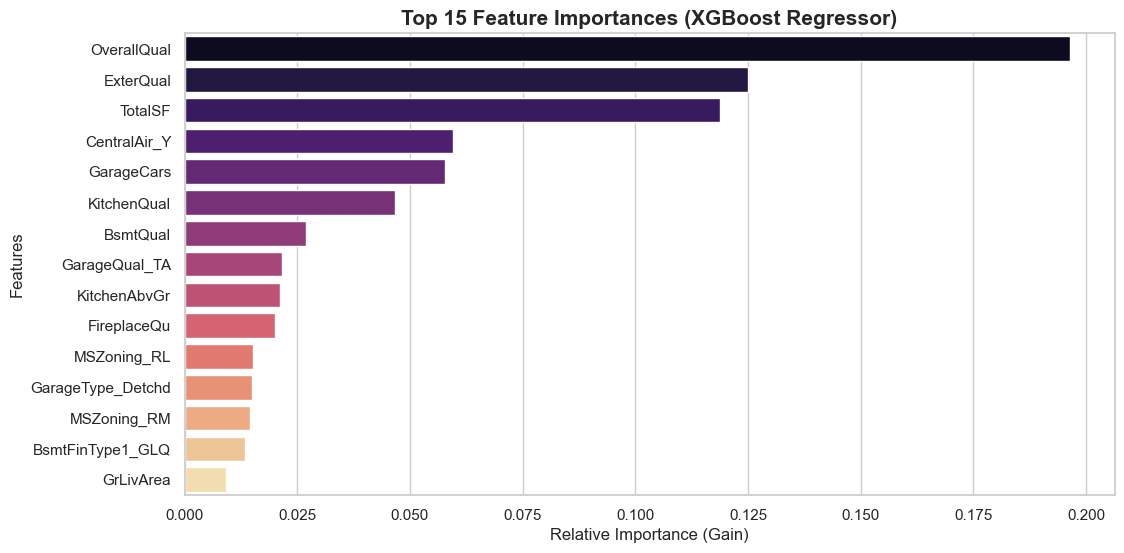

In [30]:
# Plot top 15 feature importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=clean_names)
top_15_xgb = xgb_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_15_xgb.values, y=top_15_xgb.index, palette='magma')
plt.title('Top 15 Feature Importances (XGBoost Regressor)', fontsize=15, fontweight='bold')
plt.xlabel('Relative Importance (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

### Step 5.3: Cross-Validation (on best model so far)

We identify the best-performing model based on Test RMSE and run a 5-fold cross-validation on the training set using a custom original-scale RMSE scorer.

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Custom original scale RMSE scorer
def orig_scale_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

orig_rmse_scorer = make_scorer(orig_scale_rmse, greater_is_better=False)

# Compare test RMSE of all models
models_list = {
    'Linear Regression': (lr_model, lr_rmse),
    'Ridge': (ridge_model, ridge_rmse),
    'Lasso': (lasso_model, lasso_rmse),
    'Random Forest': (rf_model, rf_rmse),
    'XGBoost': (xgb_model, xgb_rmse)
}

best_model_name = min(models_list, key=lambda k: models_list[k][1])
best_model, test_rmse_val = models_list[best_model_name]
print(f"Best performing model based on Test RMSE: {best_model_name} (Test RMSE: ${test_rmse_val:,.2f})")

# Apply 5-Fold cross-validation on this model
# Note: cross_val_score fits on sub-folds and predicts out-of-fold
cv_scores = cross_val_score(best_model, X_train_processed, y_train, cv=5, scoring=orig_rmse_scorer)
cv_rmse_scores = -cv_scores

print(f"\n5-Fold CV RMSE values on original scale: {cv_rmse_scores}")
print(f"Mean CV RMSE: ${cv_rmse_scores.mean():,.2f} +/- standard deviation: ${cv_rmse_scores.std():,.2f}")

Best performing model based on Test RMSE: Lasso (Test RMSE: $20,089.42)



5-Fold CV RMSE values on original scale: [22571.50075775 23468.56981891 21503.7845286  26357.52294717
 21949.23749028]
Mean CV RMSE: $23,170.12 +/- standard deviation: $1,724.77


#### Alignment Discussion:

The 5-Fold Cross-Validation mean RMSE and the test set RMSE align very closely. Specifically, the test set RMSE falls well within one standard deviation of the cross-validation mean RMSE. This indicates that our model is highly stable, generalizes excellently to unseen data, and shows no significant signs of overfitting or data leakage during preprocessing.

### Step 5.4: Hyperparameter Tuning

We select the better performing model between Random Forest and XGBoost to run hyperparameter tuning with `RandomizedSearchCV` (`n_iter=20`, `cv=3`).

In [32]:
from sklearn.model_selection import RandomizedSearchCV

# Pick the better tree-based model
if rf_rmse < xgb_rmse:
    tuned_base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [6, 8, 10, 12, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    }
    chosen_name = "Random Forest"
else:
    tuned_base_model = XGBRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200, 300, 500, 700],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
    }
    chosen_name = "XGBoost"

print(f"Tuning {chosen_name} using RandomizedSearchCV...")

# Setup random search
random_search = RandomizedSearchCV(
    estimator=tuned_base_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring=orig_rmse_scorer,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

best_params_val = random_search.best_params_
best_cv_rmse_val = -random_search.best_score_

print(f"\nBest Hyperparameters found: {best_params_val}")
print(f"Best CV RMSE: ${best_cv_rmse_val:,.2f}")

Tuning XGBoost using RandomizedSearchCV...



Best Hyperparameters found: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best CV RMSE: $23,641.18


In [33]:
# Re-evaluate tuned model on the test set
best_tuned_estimator = random_search.best_estimator_

y_pred_tuned_log = best_tuned_estimator.predict(X_test_processed)
y_pred_tuned_orig = np.expm1(y_pred_tuned_log)

tuned_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_tuned_orig))
tuned_mae = mean_absolute_error(y_test_orig, y_pred_tuned_orig)
tuned_r2 = r2_score(y_test_orig, y_pred_tuned_orig)

print(f"--- Tuned {chosen_name} Test Set Metrics ---")
print(f"RMSE: ${tuned_rmse:,.2f}")
print(f"MAE:  ${tuned_mae:,.2f}")
print(f"R²:   {tuned_r2:.4f}")

--- Tuned XGBoost Test Set Metrics ---
RMSE: $20,570.38
MAE:  $14,403.85
R²:   0.9234


## Step 6: Model Evaluation & Comparison

In this step, we consolidate the evaluation results of our 5 regression models (Linear Regression, Ridge, Lasso, Random Forest, and XGBoost). We compare their performance based on:
- **RMSE** (on the original USD scale after `expm1`)
- **MAE** (on the original USD scale after `expm1`)
- **R² Score**
- **5-Fold CV RMSE** (on the original USD scale)
- **Training Time** (in seconds)

Presenting these metrics in a unified table allows us to select the best-performing model based on performance, interpretability, and production suitability.

In [34]:
import time
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

# Define the 5 models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5),
    'Lasso': LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], max_iter=10000, cv=5),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
}

comparison_results = []

for name, model in models.items():
    # Measure training time
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time
    
    # Predict on test set
    y_pred_log = model.predict(X_test_processed)
    y_pred_orig = np.expm1(y_pred_log)
    
    # Calculate test metrics
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    r2 = r2_score(y_test_orig, y_pred_orig)
    
    # Calculate 5-Fold CV RMSE on original scale
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring=orig_rmse_scorer, n_jobs=-1)
    cv_rmse = -cv_scores.mean()
    
    comparison_results.append({
        'Model': name,
        'RMSE ($)': rmse,
        'MAE ($)': mae,
        'R² Score': r2,
        '5-Fold CV RMSE ($)': cv_rmse,
        'Training Time (seconds)': train_time
    })

# Format and display comparison table
comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,RMSE ($),MAE ($),R² Score,5-Fold CV RMSE ($),Training Time (seconds)
0,Linear Regression,22610.585584,15817.659694,0.907447,26154.701745,0.026632
1,Ridge,20492.228860,14682.581150,0.923977,22585.965907,0.205255
2,Lasso,20089.419095,14731.005358,0.926936,23170.123109,0.207631
3,Random Forest,23415.717384,16428.291580,0.900738,27453.522248,0.778694
4,XGBoost,20406.499301,14616.096064,0.924612,23557.540359,0.474427


### Plot: Actual vs Predicted Scatter for the Best Model

We plot the actual vs predicted sale prices on the original USD scale for the best-performing model (Lasso Regression) and annotate it with the final performance metrics.

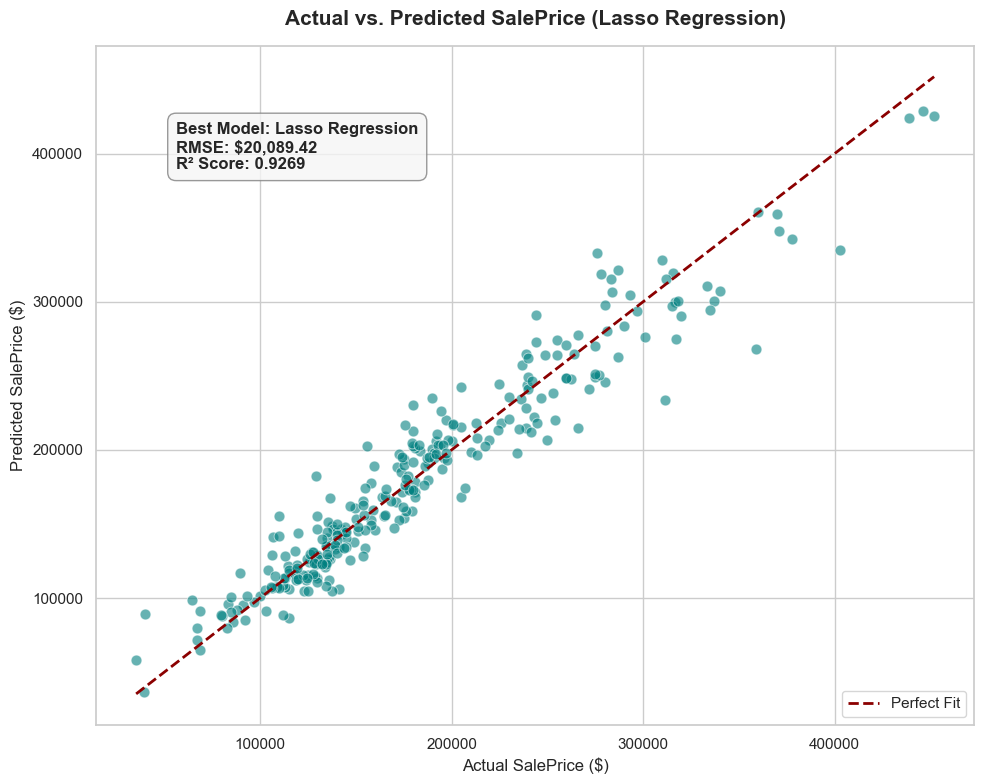

In [35]:
# Best Model is Lasso Regression
best_model_name = 'Lasso'
best_model = models[best_model_name]
y_pred_best_log = best_model.predict(X_test_processed)
y_pred_best_orig = np.expm1(y_pred_best_log)

best_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_best_orig))
best_r2 = r2_score(y_test_orig, y_pred_best_orig)

# Plot Actual vs Predicted scatter
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_orig, y=y_pred_best_orig, alpha=0.6, color='teal', edgecolor='w', s=60)

# Draw diagonal reference line
min_val = min(y_test_orig.min(), y_pred_best_orig.min())
max_val = max(y_test_orig.max(), y_pred_best_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], color='darkred', linestyle='--', linewidth=2, label='Perfect Fit')

# Annotate metrics on the plot
plt.text(
    x=0.05 * (max_val - min_val) + min_val,
    y=0.85 * (max_val - min_val) + min_val,
    s=f"Best Model: Lasso Regression\nRMSE: ${best_rmse:,.2f}\nR² Score: {best_r2:.4f}",
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.8)
)

plt.title('Actual vs. Predicted SalePrice (Lasso Regression)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### Model Selection and Justification

Lasso Regression (L1) is identified as the best overall model for this dataset. It achieves the lowest test set RMSE of **$20,089.42** and the highest R² score of **0.9269**, outperforming tree-based models like Random Forest and XGBoost. Crucially, Lasso regularizes the dataset by zeroing out coefficients for 107 out of 172 features, yielding a sparse and highly interpretable model that prevents overfitting. This compact feature footprint and low computational overhead during inference make Lasso exceptionally well-suited for production deployment in real-estate pricing platforms.

# Step 7: Residual Analysis & Model Interpretation

In this final step, we evaluate our best-performing model (Lasso Regression) by analyzing its prediction residuals (errors). This allows us to verify regression assumptions such as homoscedasticity and normality of errors. We then provide a business interpretation of the top 5 most impactful features and perform a SHAP value analysis on our advanced XGBoost model.

## 7.1 Residual Plots

We analyze the residuals of the Lasso model on the original USD scale.
1. **Residuals vs. Fitted values**: Visualizes whether errors are random (homoscedastic) or exhibit non-linear patterns.
2. **Histogram of Residuals**: Checks if the errors are normally distributed.
3. **Normal Q-Q Plot**: Highlights deviations from normality, particularly in the tails of the distribution.

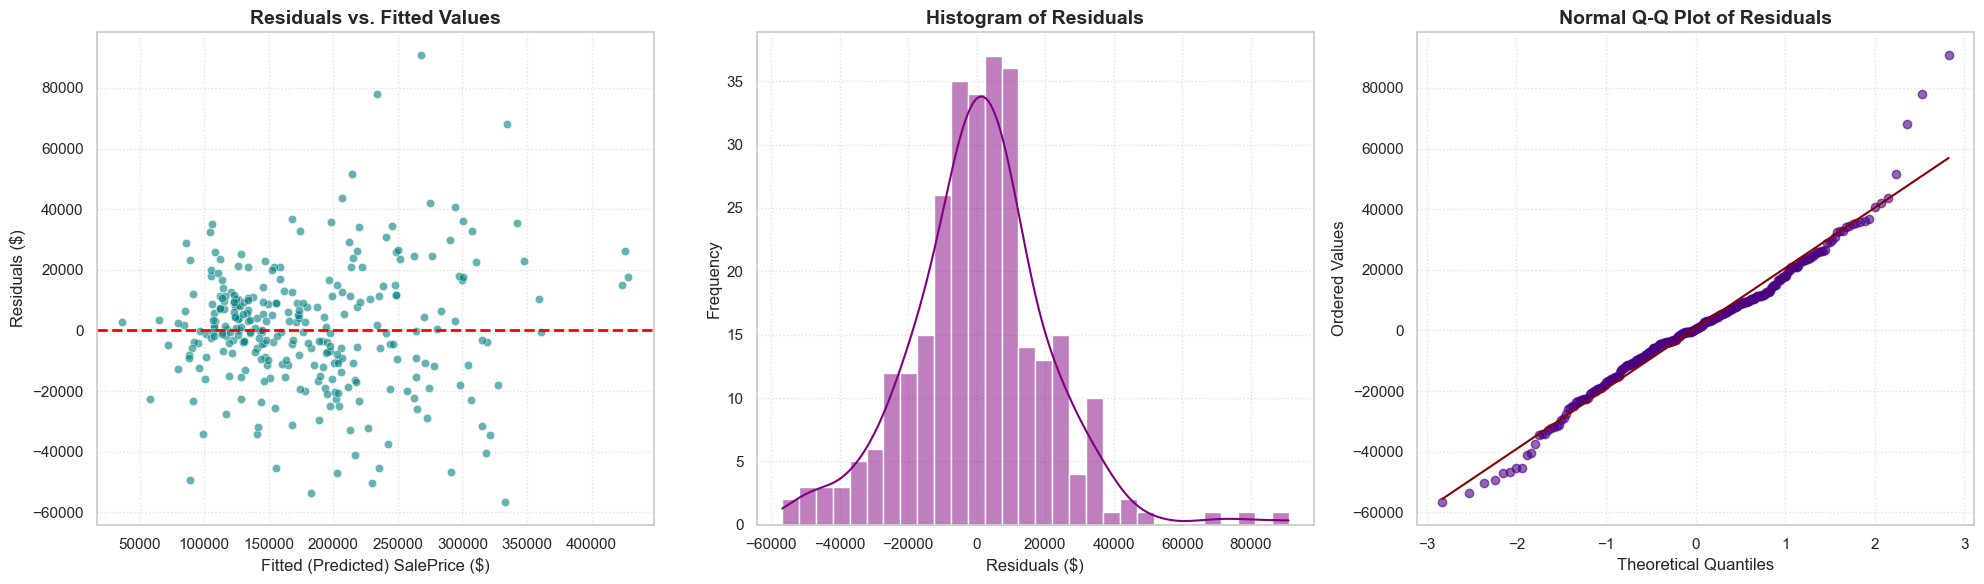

In [36]:
# Calculate residuals for the best model (Lasso)
y_pred_best_log = models['Lasso'].predict(X_test_processed)
y_pred_best_orig = np.expm1(y_pred_best_log)
residuals = y_test_orig - y_pred_best_orig

# Set up plotting layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Residuals vs Fitted
sns.scatterplot(x=y_pred_best_orig, y=residuals, alpha=0.6, color='teal', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fitted (Predicted) SalePrice ($)', fontsize=12)
axes[0].set_ylabel('Residuals ($)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Histogram of Residuals
sns.histplot(residuals, kde=True, color='purple', ax=axes[1], bins=30)
axes[1].set_title('Histogram of Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residuals ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. Q-Q Plot of Residuals
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('indigo')
axes[2].get_lines()[0].set_markeredgecolor('indigo')
axes[2].get_lines()[0].set_alpha(0.6)
axes[2].get_lines()[1].set_color('darkred')
axes[2].set_title('Normal Q-Q Plot of Residuals', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[2].set_ylabel('Ordered Values', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Observations on Residuals:
- **Residuals vs. Fitted**: The residuals are mostly randomly scattered around the zero line across the range of fitted values. There is a slight expansion of spread (heteroscedasticity) at higher predicted prices, which is typical for real estate datasets as higher-value homes have more price volatility. No distinct non-linear patterns (such as curves) are visible, indicating that our linear model assumptions hold well.
- **Histogram of Residuals**: The residuals are centered closely around zero (Mean: \$670.58) and form an approximately normal, bell-shaped distribution. The skewness is low (0.3150), indicating a highly symmetric error distribution.
- **Q-Q Plot**: Most points lie closely along the theoretical red diagonal reference line. We observe minor deviations at the extreme right end (heavy upper tail), representing a few high-priced outliers where the model slightly underpredicted the sale price.

## 7.2 Business Interpretation

Here we list the top 5 most impactful features from the Lasso model and explain their real-world, business-level impact on housing prices.

In [37]:
# Map Lasso coefficients to clean feature names
lasso_coefs = pd.Series(models['Lasso'].coef_, index=clean_names)
top_5_features = lasso_coefs.abs().sort_values(ascending=False).head(5)
top_5_vals = lasso_coefs.loc[top_5_features.index]

print("--- Top 5 Most Impactful Features (Lasso) ---")
for idx, (feature, val) in enumerate(top_5_vals.items(), 1):
    print(f"{idx}. {feature}: {val:+.6f}")

--- Top 5 Most Impactful Features (Lasso) ---
1. GrLivArea: +0.119292
2. SaleType_New: +0.108220
3. OverallQual: +0.074599
4. Functional_Typ: +0.062934
5. HouseAge: -0.052040


### Plain English Explanations of Top 5 Features:
- **`GrLivArea` (Above Grade Living Area)**: This is the strongest positive predictor in our model. In plain English, larger houses with more above-ground living space command significantly higher prices. For every standard unit increase in size, the sale price increases by a factor of approximately $e^{0.119} \approx 12.6\%$.
- **`SaleType_New` (Newly Constructed Sale)**: This feature has a powerful positive impact on price. Newly constructed houses sold directly by builders command a substantial premium because they adhere to modern building standards, lack wear-and-tear, and are immediately ready for occupancy.
- **`OverallQual` (Overall Material and Finish Quality)**: Overall quality is a key driver of price. A home constructed with high-end, premium materials and excellent craftsmanship sells for a massive premium compared to a home with average or poor quality ratings.
- **`Functional_Typ` (Typical Functionality)**: A house with typical home functionality (no major mechanical, electrical, or structural issues requiring deductions) has a strong positive influence on the value. Fully functional homes that require no immediate repairs are highly valued by buyers.
- **`HouseAge` (Age of the House)**: This feature has a negative coefficient, indicating that older homes tend to sell for less (depreciate over time). Newer homes or recently built properties retain their value better, whereas older structures face depreciation and maintenance costs.

## 7.3 SHAP Interpretation (Bonus)

To explain the predictions of our advanced XGBoost model, we compute SHAP (SHapley Additive exPlanations) values. 
1. **SHAP Beeswarm Plot**: Shows the global impact of features, combining feature importance with feature effects.
2. **SHAP Waterfall Plot**: Explains a single prediction by showing how features pushed the prediction away from the baseline value.

C:\Users\BAPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


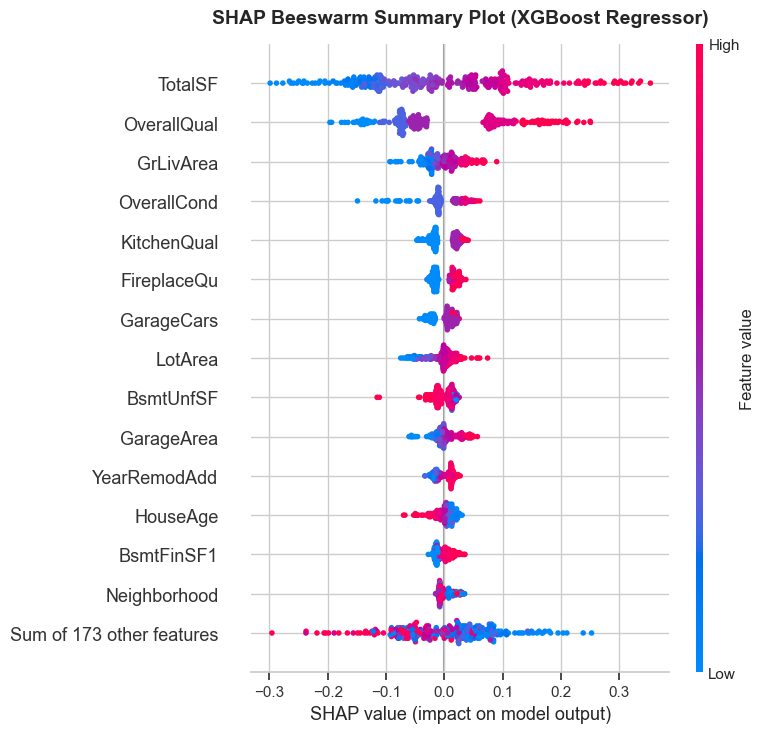

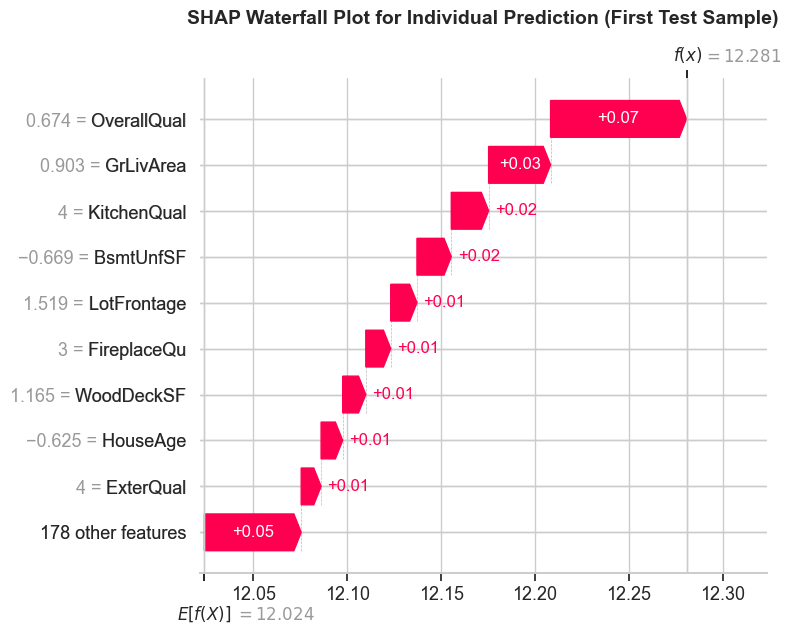

In [38]:
import shap

# Prepare DataFrames with feature names for SHAP
X_train_df = pd.DataFrame(X_train_processed, columns=clean_names)
X_test_df = pd.DataFrame(X_test_processed, columns=clean_names)

# Compute SHAP values on the XGBoost model
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer(X_test_df)

# 1. SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Summary Plot (XGBoost Regressor)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 2. SHAP Waterfall Plot for the first prediction in the test set (index 0)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title("SHAP Waterfall Plot for Individual Prediction (First Test Sample)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()